# CORe50 Task-Reordering Robustness Experiment

**CpE 620 — Spring 2026**

This notebook tests whether the continual-learning results are sensitive to task order by
repeating the seven-task CORe50 New Classes experiment with the sequence:

**2 → 0 → 6 → 4 → 1 → 3 → 5**

The same comparison framework is retained so that task-order robustness can be assessed directly.
This portfolio copy preserves the original experimental logic and saved results while removing
installation-only material and noisy download output.


In [ ]:
# ============================================================
# CELL 2 — Imports and reproducibility
# ============================================================
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from torchvision import transforms
from avalanche.benchmarks.classic import CORe50

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# ============================================================
# CELL 3 — CORe50 root and transforms
# ============================================================
core50_root = "./core50_data"

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

In [ ]:
# ============================================================
# CELL 4 — Load CORe50 benchmark and apply a fixed permuted task order
# ============================================================
benchmark = CORe50(
    scenario="nc",
    run=0,
    object_lvl=True,
    mini=False,
    train_transform=train_transform,
    eval_transform=eval_transform,
    dataset_root=core50_root
)

# Limit to first 7 original tasks
num_tasks_to_use = 7

original_train_stream = benchmark.train_stream[:num_tasks_to_use]
original_test_stream = benchmark.test_stream[:num_tasks_to_use]

print("Original number of training experiences:", len(original_train_stream))
print("Original number of test experiences:", len(original_test_stream))

# ============================================================
# FIXED PERMUTED TASK ORDER
# Example: train in this order:
# Original Task 2 → Original Task 0 → Original Task 6 → Original Task 4
# → Original Task 1 → Original Task 3 → Original Task 5
# ============================================================
task_order = [2, 0, 6, 4, 1, 3, 5]

assert sorted(task_order) == list(range(num_tasks_to_use)), "task_order must contain each task index exactly once."

# Reorder train stream according to task_order
train_stream = [original_train_stream[i] for i in task_order]

# Keep test_stream as returned. If only one complete test set exists,
# CELL 7 will split it by the reordered task classes.
test_stream = original_test_stream

print("Randomized task order:", task_order)
print("Number of training experiences used:", len(train_stream))
print("Number of test experiences used:", len(test_stream))

Loading labels...
Loading LUP...
Loading labels names...
Original number of training experiences: 7
Original number of test experiences: 1
Randomized task order: [2, 0, 6, 4, 1, 3, 5]
Number of training experiences used: 7
Number of test experiences used: 1


In [ ]:
# ============================================================
# CELL 5 — Inspect experiences AFTER random ordering
# ============================================================
exp_classes = []
original_task_ids = []

for new_task_id, exp in enumerate(train_stream):
    cls = sorted(list(exp.classes_in_this_experience))
    exp_classes.append(cls)
    original_task_ids.append(exp.current_experience)

    print(
        f"New Task {new_task_id} "
        f"(Original Experience {exp.current_experience}): "
        f"classes={cls}, num_samples={len(exp.dataset)}"
    )

num_tasks = len(exp_classes)
head_sizes = [len(cls) for cls in exp_classes]

print("num_tasks =", num_tasks)
print("head_sizes =", head_sizes)
print("Training order in original task IDs =", original_task_ids)

New Task 0 (Original Experience 2): classes=[15, 16, 17, 18, 19], num_samples=11990
New Task 1 (Original Experience 0): classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], num_samples=23980
New Task 2 (Original Experience 6): classes=[35, 36, 37, 38, 39], num_samples=11990
New Task 3 (Original Experience 4): classes=[25, 26, 27, 28, 29], num_samples=11989
New Task 4 (Original Experience 1): classes=[10, 11, 12, 13, 14], num_samples=11993
New Task 5 (Original Experience 3): classes=[20, 21, 22, 23, 24], num_samples=11993
New Task 6 (Original Experience 5): classes=[30, 31, 32, 33, 34], num_samples=11979
num_tasks = 7
head_sizes = [5, 10, 5, 5, 5, 5, 5]
Training order in original task IDs = [2, 0, 6, 4, 1, 3, 5]


In [ ]:
# ============================================================
# CELL 6 — Optional subset for speed
# ============================================================
subset_fraction = 0.5

def maybe_subset_dataset(dataset, fraction=0.5, seed=42):
    if fraction >= 1.0:
        return dataset

    n = len(dataset)
    k = max(1, int(n * fraction))
    rng = np.random.default_rng(seed)
    idx = rng.choice(np.arange(n), size=k, replace=False)
    idx = sorted(idx.tolist())
    return Subset(dataset, idx)

In [ ]:
# ============================================================
# CELL 7 — Build train/test datasets per task (RANDOM ORDER SAFE)
# ============================================================
train_datasets = []
test_datasets = []

# -----------------------------
# Training datasets: already reordered
# -----------------------------
for i, exp in enumerate(train_stream):
    train_datasets.append(
        maybe_subset_dataset(exp.dataset, fraction=subset_fraction, seed=42 + i)
    )

# -----------------------------
# Test datasets:
# Case 1 -> test_stream already has one test experience per task
# Case 2 -> test_stream has only one complete test set
#          then split it manually by REORDERED task classes
# -----------------------------
if len(test_stream) == num_tasks:
    # If Avalanche returns one test experience per task, reorder it too.
    reordered_test_stream = [test_stream[i] for i in task_order]

    for i, exp in enumerate(reordered_test_stream):
        test_datasets.append(
            maybe_subset_dataset(exp.dataset, fraction=1.0, seed=100 + i)
        )
else:
    print(f"test_stream has {len(test_stream)} experience(s); building per-task test subsets from the complete test set.")

    full_test_dataset = test_stream[0].dataset

    def get_label_from_sample(sample):
        if isinstance(sample, (list, tuple)) and len(sample) >= 2:
            return int(sample[1])
        raise ValueError("Unexpected sample format while extracting labels from test dataset.")

    for i, cls_list in enumerate(exp_classes):
        allowed = set(cls_list)
        indices = [
            idx for idx in range(len(full_test_dataset))
            if get_label_from_sample(full_test_dataset[idx]) in allowed
        ]
        task_subset = Subset(full_test_dataset, indices)
        test_datasets.append(task_subset)

# -----------------------------
# Sanity check
# -----------------------------
print("Number of train task datasets:", len(train_datasets))
print("Number of test task datasets :", len(test_datasets))

for i in range(len(train_datasets)):
    print(
        f"New Task {i} "
        f"(Original Task {original_task_ids[i]}): "
        f"train={len(train_datasets[i])}, test={len(test_datasets[i])}"
    )

test_stream has 1 experience(s); building per-task test subsets from the complete test set.
Number of train task datasets: 7
Number of test task datasets : 7
New Task 0 (Original Task 2): train=5995, test=4500
New Task 1 (Original Task 0): train=11990, test=8993
New Task 2 (Original Task 6): train=5995, test=4495
New Task 3 (Original Task 4): train=5994, test=4500
New Task 4 (Original Task 1): train=5996, test=4495
New Task 5 (Original Task 3): train=5996, test=4493
New Task 6 (Original Task 5): train=5989, test=4500


In [ ]:
# ============================================================
# CELL 8 — Dataloaders
# ============================================================
batch_size = 64

train_loaders = [
    DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    for ds in train_datasets
]

test_loaders = [
    DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    for ds in test_datasets
]

In [ ]:
# ============================================================
# CELL 9 — Label remapping per reordered experience
# ============================================================
class_maps = []
for cls in exp_classes:
    local_map = {global_label: local_idx for local_idx, global_label in enumerate(cls)}
    class_maps.append(local_map)

def remap_labels(y, task_id):
    mapper = class_maps[task_id]
    y_cpu = y.detach().cpu().tolist()
    local = [mapper[int(label)] for label in y_cpu]
    return torch.tensor(local, dtype=torch.long, device=y.device)

In [ ]:
# ============================================================
# CELL 10 — Batch unpacking helper
# ============================================================
def unpack_batch(batch):
    if isinstance(batch, (list, tuple)) and len(batch) >= 2:
        x = batch[0]
        y = batch[1]
        return x, y
    raise ValueError("Unexpected batch format")

In [ ]:
# ============================================================
# CELL 11 — Backbone and multi-head model
# ============================================================
class CORe50Backbone(nn.Module):
    def __init__(self, feat_dim=512):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, feat_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x


class MultiHeadCORe50Net(nn.Module):
    def __init__(self, head_sizes, feat_dim=512):
        super().__init__()
        self.backbone = CORe50Backbone(feat_dim=feat_dim)
        self.heads = nn.ModuleList([nn.Linear(feat_dim, h) for h in head_sizes])

    def forward(self, x, task_id):
        feats = self.backbone(x)
        return self.heads[task_id](feats)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = MultiHeadCORe50Net(head_sizes=head_sizes).to(device)
print("Trainable parameters:", count_params(model))

Trainable parameters: 2611560


In [ ]:
# ============================================================
# CELL 12 — Evaluation utilities
# ============================================================
@torch.no_grad()
def evaluate_task(model, loader, task_id):
    model.eval()
    total, correct = 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), y.to(device)

        y_t = remap_labels(y, task_id)
        logits = model(x, task_id)
        pred = logits.argmax(dim=1)

        total += y_t.size(0)
        correct += (pred == y_t).sum().item()

    return correct / total


def evaluate_seen_tasks(model, seen_tasks):
    return [evaluate_task(model, test_loaders[t], t) for t in seen_tasks]


def print_seen_task_summary(model, seen_tasks, note=""):
    accs = evaluate_seen_tasks(model, seen_tasks)
    mean_acc = np.mean(accs) if len(accs) > 0 else 0.0

    task_labels = [
        f"T{t}(Orig {original_task_ids[t]}):{accs[i]:.4f}"
        for i, t in enumerate(seen_tasks)
    ]

    print(
        f"{note} | " +
        ", ".join(task_labels) +
        f" | Mean:{mean_acc:.4f}"
    )
    return accs, mean_acc

In [ ]:
# ============================================================
# CELL 13 — Training helpers
# ============================================================
def set_trainable(model, train_backbone=True, train_heads=None):
    for p in model.backbone.parameters():
        p.requires_grad = train_backbone

    if train_heads is None:
        for head in model.heads:
            for p in head.parameters():
                p.requires_grad = True
    else:
        for i, head in enumerate(model.heads):
            flag = i in train_heads
            for p in head.parameters():
                p.requires_grad = flag


def get_optimizer(model, lr=1e-3, weight_decay=1e-4):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)


def train_one_epoch(model, loader, optimizer, task_id, extra_loss_fn=None):
    model.train()
    total_loss = 0.0
    total = 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), y.to(device)
        y_t = remap_labels(y, task_id)

        optimizer.zero_grad()
        logits = model(x, task_id)
        loss = F.cross_entropy(logits, y_t)

        if extra_loss_fn is not None:
            loss = loss + extra_loss_fn(model)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y_t.size(0)
        total += y_t.size(0)

    return total_loss / total

In [ ]:
# ============================================================
# CELL 14 — Forgetting metric
# ============================================================
def compute_forgetting(acc_matrix):
    forgetting_per_task = {}
    final_row = acc_matrix[-1]

    for task_j in range(len(final_row)):
        prev = [acc_matrix[i][task_j] for i in range(len(acc_matrix)) if acc_matrix[i][task_j] is not None]
        if len(prev) == 0:
            continue
        best_before_final = max(prev[:-1]) if len(prev) > 1 else prev[0]
        final_acc = final_row[task_j]
        forgetting_per_task[task_j] = best_before_final - final_acc

    mean_forgetting = np.mean(list(forgetting_per_task.values()))
    return forgetting_per_task, mean_forgetting


def final_avg_accuracy(acc_matrix):
    return np.mean([x for x in acc_matrix[-1] if x is not None])

In [ ]:
# ============================================================
# CELL 15 — EWC helpers
# ============================================================
def snapshot_backbone(model):
    return {n: p.detach().clone() for n, p in model.backbone.named_parameters()}

def compute_fisher_diag_backbone(model, data_loader, task_id, num_batches=100):
    model.eval()

    fisher = {
        n: torch.zeros_like(p, device=device)
        for n, p in model.backbone.named_parameters()
    }

    count = 0
    for batch in data_loader:
        x, y = unpack_batch(batch)
        x, y = x.to(device), y.to(device)
        y_t = remap_labels(y, task_id)

        model.zero_grad()
        logits = model(x, task_id)
        loss = F.cross_entropy(logits, y_t)
        loss.backward()

        for n, p in model.backbone.named_parameters():
            if p.grad is not None:
                fisher[n] += (p.grad.detach() ** 2)

        count += 1
        if count >= num_batches:
            break

    for n in fisher:
        fisher[n] /= max(count, 1)

    return fisher


class EWCBackbone:
    def __init__(self, fisher, theta_old, lam=500.0):
        self.fisher = fisher
        self.theta_old = theta_old
        self.lam = lam

    def penalty(self, model):
        loss = 0.0
        for n, p in model.backbone.named_parameters():
            loss += (self.fisher[n] * (p - self.theta_old[n]) ** 2).sum()
        return self.lam * loss


def add_fishers(fisher_a, fisher_b):
    if fisher_a is None:
        return {k: v.clone() for k, v in fisher_b.items()}
    return {k: fisher_a[k] + fisher_b[k] for k in fisher_a}

def average_fisher(fisher, divisor):
    return {k: fisher[k] / divisor for k in fisher}

In [ ]:
# ============================================================
# CELL 16 — Intentional forgetting
# ============================================================
@torch.no_grad()
def targeted_forgetting_backbone(model, fisher, forget_rate=1e-4, percentile=10):
    for n, p in model.backbone.named_parameters():
        Fval = fisher[n]
        thresh = torch.quantile(Fval.view(-1), percentile / 100.0)
        low_mask = (Fval <= thresh)
        p[low_mask] *= (1.0 - forget_rate)

In [ ]:
# ============================================================
# CELL 17 — Sequential Fine-Tuning
# ============================================================
def run_sequential_finetuning(epochs_per_task=5):
    model = MultiHeadCORe50Net(head_sizes=head_sizes).to(device)
    acc_matrix = []
    mean_history = []

    print("\n========== SEQUENTIAL FINE-TUNING ON CORe50 ==========")
    print("Training order:", [f"New T{i}=Original T{original_task_ids[i]}" for i in range(num_tasks)])

    for current_task in range(num_tasks):
        print(f"\n--- Training Sequential on New Task {current_task} (Original Task {original_task_ids[current_task]}) ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task)
            _, mean_acc = print_seen_task_summary(
                model,
                list(range(current_task + 1)),
                note=f"Sequential NewT{current_task}/OrigT{original_task_ids[current_task]} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 18 — EWC
# ============================================================
def run_ewc(epochs_per_task=5, lam=500.0):
    model = MultiHeadCORe50Net(head_sizes=head_sizes).to(device)
    acc_matrix = []
    mean_history = []

    consolidated_fisher = None
    task_snapshots = []
    num_consolidated_tasks = 0

    print("\n========== EWC ON CORe50 ==========")
    print("Training order:", [f"New T{i}=Original T{original_task_ids[i]}" for i in range(num_tasks)])

    for current_task in range(num_tasks):
        print(f"\n--- Training EWC on New Task {current_task} (Original Task {original_task_ids[current_task]}) ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        if current_task == 0:
            extra_loss_fn = None
        else:
            avg_fisher = average_fisher(consolidated_fisher, num_consolidated_tasks)
            theta_old = task_snapshots[-1]
            ewc = EWCBackbone(avg_fisher, theta_old, lam=lam)
            extra_loss_fn = ewc.penalty

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task, extra_loss_fn=extra_loss_fn)
            _, mean_acc = print_seen_task_summary(
                model,
                list(range(current_task + 1)),
                note=f"EWC NewT{current_task}/OrigT{original_task_ids[current_task]} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

        fisher_t = compute_fisher_diag_backbone(model, train_loaders[current_task], current_task, num_batches=100)
        consolidated_fisher = add_fishers(consolidated_fisher, fisher_t)
        task_snapshots.append(snapshot_backbone(model))
        num_consolidated_tasks += 1

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 19 — Proposed Method: Adaptive Consolidation + Intentional Forgetting
# ============================================================
def run_proposed(epochs_per_task=5, lam=700.0, forget_rate=1e-4, percentile=10):
    model = MultiHeadCORe50Net(head_sizes=head_sizes).to(device)
    acc_matrix = []
    mean_history = []

    consolidated_fisher = None
    task_snapshots = []
    num_consolidated_tasks = 0

    print("\n========== PROPOSED METHOD ON CORe50 ==========")
    print("Training order:", [f"New T{i}=Original T{original_task_ids[i]}" for i in range(num_tasks)])

    for current_task in range(num_tasks):
        print(f"\n--- Training Proposed Method on New Task {current_task} (Original Task {original_task_ids[current_task]}) ---")

        set_trainable(model, train_backbone=True, train_heads=[current_task])
        optimizer = get_optimizer(model, lr=1e-3, weight_decay=1e-4)

        if current_task == 0:
            extra_loss_fn = None
            avg_fisher = None
        else:
            avg_fisher = average_fisher(consolidated_fisher, num_consolidated_tasks)
            theta_old = task_snapshots[-1]
            ewc = EWCBackbone(avg_fisher, theta_old, lam=lam)
            extra_loss_fn = ewc.penalty

        for ep in range(1, epochs_per_task + 1):
            loss = train_one_epoch(model, train_loaders[current_task], optimizer, current_task, extra_loss_fn=extra_loss_fn)

            if current_task > 0:
                targeted_forgetting_backbone(
                    model,
                    avg_fisher,
                    forget_rate=forget_rate,
                    percentile=percentile
                )

            _, mean_acc = print_seen_task_summary(
                model,
                list(range(current_task + 1)),
                note=f"Proposed NewT{current_task}/OrigT{original_task_ids[current_task]} Ep{ep} | loss={loss:.4f}"
            )

        row = [None] * num_tasks
        seen_accs = evaluate_seen_tasks(model, list(range(current_task + 1)))
        for t in range(current_task + 1):
            row[t] = seen_accs[t]
        acc_matrix.append(row)
        mean_history.append(np.mean(seen_accs))

        fisher_t = compute_fisher_diag_backbone(model, train_loaders[current_task], current_task, num_batches=100)
        consolidated_fisher = add_fishers(consolidated_fisher, fisher_t)
        task_snapshots.append(snapshot_backbone(model))
        num_consolidated_tasks += 1

    return model, acc_matrix, mean_history

In [ ]:
# ============================================================
# CELL 20 — Run all methods
# ============================================================
epochs_per_task = 5
lam = 500.0
forget_rate = 1e-4

print("FINAL RANDOMIZED TRAINING ORDER:")
for new_t, old_t in enumerate(original_task_ids):
    print(f"New Task {new_t} = Original Task {old_t}, Classes = {exp_classes[new_t]}")

seq_model, seq_acc_matrix, seq_mean_hist = run_sequential_finetuning(epochs_per_task=epochs_per_task)
ewc_model, ewc_acc_matrix, ewc_mean_hist = run_ewc(epochs_per_task=epochs_per_task, lam=lam)
prop_model, prop_acc_matrix, prop_mean_hist = run_proposed(
    epochs_per_task=epochs_per_task,
    lam=lam,
    forget_rate=forget_rate,
    percentile=10
)

FINAL RANDOMIZED TRAINING ORDER:
New Task 0 = Original Task 2, Classes = [15, 16, 17, 18, 19]
New Task 1 = Original Task 0, Classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
New Task 2 = Original Task 6, Classes = [35, 36, 37, 38, 39]
New Task 3 = Original Task 4, Classes = [25, 26, 27, 28, 29]
New Task 4 = Original Task 1, Classes = [10, 11, 12, 13, 14]
New Task 5 = Original Task 3, Classes = [20, 21, 22, 23, 24]
New Task 6 = Original Task 5, Classes = [30, 31, 32, 33, 34]

========== SEQUENTIAL FINE-TUNING ON CORe50 ==========
Training order: ['New T0=Original T2', 'New T1=Original T0', 'New T2=Original T6', 'New T3=Original T4', 'New T4=Original T1', 'New T5=Original T3', 'New T6=Original T5']

--- Training Sequential on New Task 0 (Original Task 2) ---
Sequential NewT0/OrigT2 Ep1 | loss=0.7485 | T0(Orig 2):0.5200 | Mean:0.5200
Sequential NewT0/OrigT2 Ep2 | loss=0.3421 | T0(Orig 2):0.5162 | Mean:0.5162
Sequential NewT0/OrigT2 Ep3 | loss=0.2436 | T0(Orig 2):0.3651 | Mean:0.3651
Sequential New

In [ ]:
# ============================================================
# CELL 21 — Final metrics
# ============================================================
seq_final_acc = final_avg_accuracy(seq_acc_matrix)
ewc_final_acc = final_avg_accuracy(ewc_acc_matrix)
prop_final_acc = final_avg_accuracy(prop_acc_matrix)

seq_forgetting_per_task, seq_mean_forgetting = compute_forgetting(seq_acc_matrix)
ewc_forgetting_per_task, ewc_mean_forgetting = compute_forgetting(ewc_acc_matrix)
prop_forgetting_per_task, prop_mean_forgetting = compute_forgetting(prop_acc_matrix)

print("Sequential Final Avg Accuracy:", seq_final_acc)
print("EWC Final Avg Accuracy       :", ewc_final_acc)
print("Proposed Final Avg Accuracy  :", prop_final_acc)

print("\nSequential Mean Forgetting:", seq_mean_forgetting)
print("EWC Mean Forgetting       :", ewc_mean_forgetting)
print("Proposed Mean Forgetting  :", prop_mean_forgetting)

Sequential Final Avg Accuracy: 0.2917670397864847
EWC Final Avg Accuracy       : 0.4080488798452055
Proposed Final Avg Accuracy  : 0.4080584844461487

Sequential Mean Forgetting: 0.36413539024901015
EWC Mean Forgetting       : 0.16722237102086326
Proposed Mean Forgetting  : 0.13924455849475215


In [ ]:
# ============================================================
# CELL 22 — Results dictionary
# ============================================================
results = {
    "Sequential Fine-Tuning": {
        "Final Avg Accuracy": seq_final_acc,
        "Mean Forgetting": seq_mean_forgetting
    },
    "EWC": {
        "Final Avg Accuracy": ewc_final_acc,
        "Mean Forgetting": ewc_mean_forgetting
    },
    "Adaptive Consolidation + Intentional Forgetting": {
        "Final Avg Accuracy": prop_final_acc,
        "Mean Forgetting": prop_mean_forgetting
    }
}
results

{'Sequential Fine-Tuning': {'Final Avg Accuracy': np.float64(0.2917670397864847),
  'Mean Forgetting': np.float64(0.36413539024901015)},
 'EWC': {'Final Avg Accuracy': np.float64(0.4080488798452055),
  'Mean Forgetting': np.float64(0.16722237102086326)},
 'Adaptive Consolidation + Intentional Forgetting': {'Final Avg Accuracy': np.float64(0.4080584844461487),
  'Mean Forgetting': np.float64(0.13924455849475215)}}

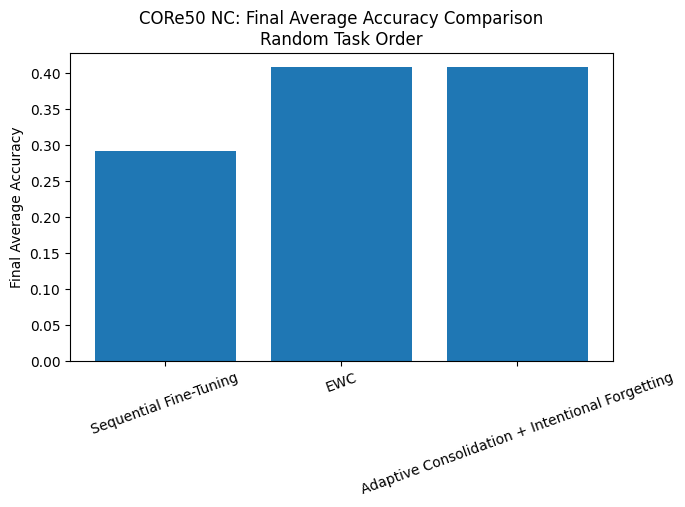

In [ ]:
# ============================================================
# CELL 23 — Plot final average accuracy
# ============================================================
labels = list(results.keys())
vals = [results[k]["Final Avg Accuracy"] for k in labels]

plt.figure(figsize=(7,4))
plt.bar(labels, vals)
plt.ylabel("Final Average Accuracy")
plt.title("CORe50 NC: Final Average Accuracy Comparison\nRandom Task Order")
plt.xticks(rotation=20)
plt.show()

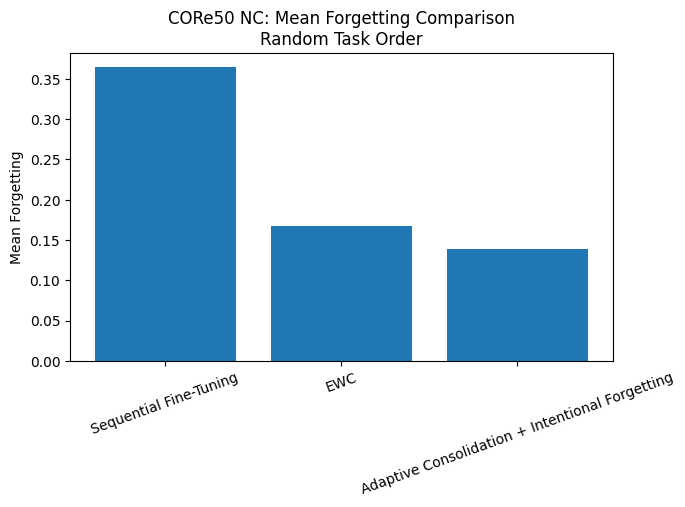

In [ ]:
# ============================================================
# CELL 24 — Plot mean forgetting
# ============================================================
labels = list(results.keys())
vals = [results[k]["Mean Forgetting"] for k in labels]

plt.figure(figsize=(7,4))
plt.bar(labels, vals)
plt.ylabel("Mean Forgetting")
plt.title("CORe50 NC: Mean Forgetting Comparison\nRandom Task Order")
plt.xticks(rotation=20)
plt.show()